Imports

In [1]:
import os
import sys
import pandas as pd

sys.path.append(os.path.dirname(os.getcwd()))

from src.config import RESULTS_CSV
print("Imports OK")

Imports OK


Visualization of actual results

In [3]:
def show_results():
    if not os.path.exists(RESULTS_CSV):
        print("No results available yet.")
        return
    df = pd.read_csv(RESULTS_CSV)
    
    # Filter only preprocessing experiments (Phase 1)
    phase1 = ['prep_none__meta_none', 'prep_dullrazor__meta_none', 
              'prep_colorconstancy__meta_none', 'prep_both__meta_none']
    df = df[df['experiment'].isin(phase1)]
    
    # Keep only relevant columns for preprocessing comparison
    cols = ['experiment', 'preprocess', 'macro_f1', 'macro_recall', 
            'roc_auc', 'melanoma_recall']
    df = df[cols].sort_values("macro_f1", ascending=False).reset_index(drop=True)
    
    pd.set_option("display.float_format", "{:.4f}".format)
    return df

show_results()

,experiment,preprocess,macro_f1,macro_recall,roc_auc,melanoma_recall
0,prep_colorconstancy__meta_none,colorconstancy,0.7700,0.8295,0.9692,0.6647
1,prep_none__meta_none,none,0.7542,0.8117,0.9680,0.6946
2,prep_dullrazor__meta_none,dullrazor,0.7327,0.8026,0.9687,0.6886
3,prep_both__meta_none,both,0.7208,0.7776,0.9582,0.6647


Preprocessing experiments (Phase 1)

In [4]:
# ── PHASE 1: Preprocessing (image only, no metadata) ─────────────────────
# Run each line in the terminal with nohup

experiments_phase1 = [
    "nohup python -m experiments.run --preprocess none         --metadata > outputs/logs/e01_baseline.log       2>&1 &",
    "nohup python -m experiments.run --preprocess dullrazor    --metadata > outputs/logs/e02_dullrazor.log      2>&1 &",
    "nohup python -m experiments.run --preprocess colorconstancy --metadata > outputs/logs/e03_colorconstancy.log 2>&1 &",
    "nohup python -m experiments.run --preprocess both         --metadata > outputs/logs/e04_both.log           2>&1 &",
]

print("Phase 1 commands — Preprocessing:")
for cmd in experiments_phase1:
    print(f"\n{cmd}")

Phase 1 commands — Preprocessing:

nohup python -m experiments.run --preprocess none         --metadata > outputs/logs/e01_baseline.log       2>&1 &

nohup python -m experiments.run --preprocess dullrazor    --metadata > outputs/logs/e02_dullrazor.log      2>&1 &

nohup python -m experiments.run --preprocess colorconstancy --metadata > outputs/logs/e03_colorconstancy.log 2>&1 &

nohup python -m experiments.run --preprocess both         --metadata > outputs/logs/e04_both.log           2>&1 &


Metadata experiments (Phase 2)

In [5]:
# ── PHASE 2: Metadata ────────────────────────────────────────────────────────
# BEST_PREP is set to the best preprocessing method from Phase 1
BEST_PREP = "colorconstancy"   # ← update when Phase 1 is complete

experiments_phase2 = [
    f"nohup python -m experiments.run --preprocess {BEST_PREP} --metadata age                    > outputs/logs/e05_age.log          2>&1 &",
    f"nohup python -m experiments.run --preprocess {BEST_PREP} --metadata sex                    > outputs/logs/e06_sex.log          2>&1 &",
    f"nohup python -m experiments.run --preprocess {BEST_PREP} --metadata localization           > outputs/logs/e07_loc.log          2>&1 &",
    f"nohup python -m experiments.run --preprocess {BEST_PREP} --metadata age sex                > outputs/logs/e08_age_sex.log      2>&1 &",
    f"nohup python -m experiments.run --preprocess {BEST_PREP} --metadata age localization       > outputs/logs/e09_age_loc.log      2>&1 &",
    f"nohup python -m experiments.run --preprocess {BEST_PREP} --metadata sex localization       > outputs/logs/e10_sex_loc.log      2>&1 &",
    f"nohup python -m experiments.run --preprocess {BEST_PREP} --metadata age sex localization   > outputs/logs/e11_all_meta.log     2>&1 &",
]

print(f"Phase 2 commands — Metadata (preprocessing: {BEST_PREP}):")
for cmd in experiments_phase2:
    print(f"\n{cmd}")

Phase 2 commands — Metadata (preprocessing: colorconstancy):

nohup python -m experiments.run --preprocess colorconstancy --metadata age                    > outputs/logs/e05_age.log          2>&1 &

nohup python -m experiments.run --preprocess colorconstancy --metadata sex                    > outputs/logs/e06_sex.log          2>&1 &

nohup python -m experiments.run --preprocess colorconstancy --metadata localization           > outputs/logs/e07_loc.log          2>&1 &

nohup python -m experiments.run --preprocess colorconstancy --metadata age sex                > outputs/logs/e08_age_sex.log      2>&1 &

nohup python -m experiments.run --preprocess colorconstancy --metadata age localization       > outputs/logs/e09_age_loc.log      2>&1 &

nohup python -m experiments.run --preprocess colorconstancy --metadata sex localization       > outputs/logs/e10_sex_loc.log      2>&1 &

nohup python -m experiments.run --preprocess colorconstancy --metadata age sex localization   > outputs/logs/e

## Phase 1 Results — Preprocessing Comparison

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sys
sys.path.append(os.path.dirname(os.getcwd()))
from src.config import RESULTS_CSV

results = pd.read_csv(RESULTS_CSV)

# Filter Phase 1 experiments
phase1_ids = ['prep_none__meta_none', 'prep_dullrazor__meta_none',
              'prep_colorconstancy__meta_none', 'prep_both__meta_none']

labels = {
    'prep_none__meta_none':             'E01 — Baseline (none)',
    'prep_dullrazor__meta_none':        'E02 — DullRazor',
    'prep_colorconstancy__meta_none':   'E03 — Color Constancy ★',
    'prep_both__meta_none':             'E04 — Both'
}

cols = ['experiment', 'macro_f1', 'macro_recall', 'roc_auc', 'melanoma_recall']
df_p1 = results[results['experiment'].isin(phase1_ids)][cols].copy()
df_p1['experiment'] = df_p1['experiment'].map(labels)
df_p1 = df_p1.set_index('experiment').loc[list(labels.values())]
df_p1.columns = ['Macro F1', 'Macro Recall', 'ROC-AUC', 'Melanoma Recall ⚠']

print("Phase 1 — Preprocessing results:")
print(df_p1.to_string())

Phase 1 — Preprocessing results:
                         Macro F1  Macro Recall  ROC-AUC  Melanoma Recall ⚠
experiment                                                                 
E01 — Baseline (none)      0.7542        0.8117   0.9680             0.6946
E02 — DullRazor            0.7327        0.8026   0.9687             0.6886
E03 — Color Constancy ★    0.7700        0.8295   0.9692             0.6647
E04 — Both                 0.7208        0.7776   0.9582             0.6647


Phase 1 graphic

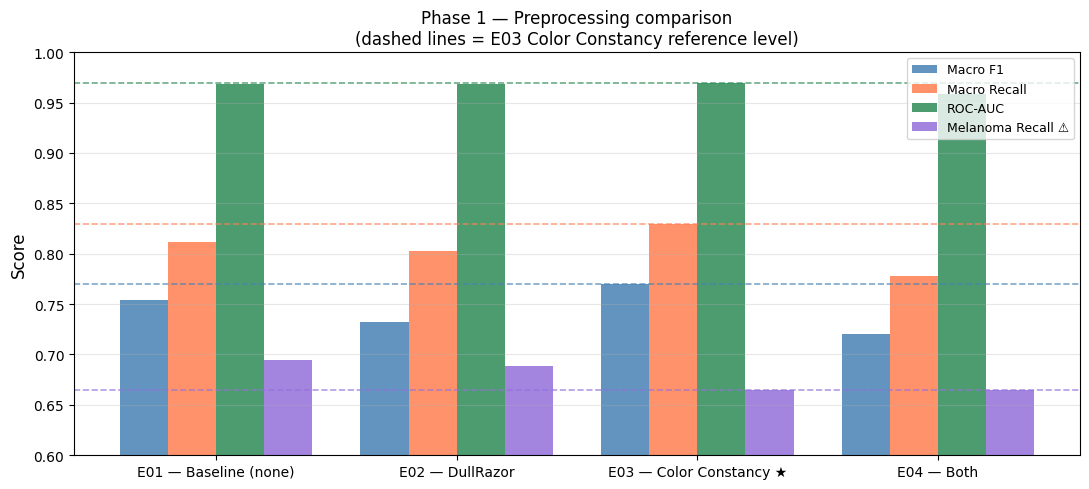

In [6]:
fig, ax = plt.subplots(figsize=(11, 5))

x = range(len(df_p1))
width = 0.2
colors = ['steelblue', 'coral', 'seagreen', 'mediumpurple']
metric_cols = ['Macro F1', 'Macro Recall', 'ROC-AUC', 'Melanoma Recall ⚠']

for i, (col, color) in enumerate(zip(metric_cols, colors)):
    offset = (i - 1.5) * width
    bars = ax.bar([xi + offset for xi in x], df_p1[col], width,
                  label=col, color=color, alpha=0.85)
    
    # Dashed line at the E03 reference level for each metric
    e03_val = df_p1.loc['E03 — Color Constancy ★', col]
    ax.axhline(y=e03_val, color=color, linestyle='--', linewidth=1.2, alpha=0.7)

ax.set_xticks(list(x))
ax.set_xticklabels(df_p1.index, fontsize=10)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Phase 1 — Preprocessing comparison\n(dashed lines = E03 Color Constancy reference level)', 
             fontsize=12)
ax.legend(fontsize=9)
ax.set_ylim(0.60, 1.0)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

### Note on Melanoma Recall in Phase 1

Although E03 does not achieve the highest Melanoma Recall in Phase 1 (0.665 vs 
0.695 for E01), preprocessing selection is based on overall model performance 
(Macro F1 and Macro Recall) rather than a single class. The Melanoma Recall 
is the clinically critical metric for **final model selection** in Phase 2, 
where the addition of clinical metadata (age and localization) raises it 
from 0.665 to 0.844 (+0.180). Optimising Melanoma Recall (by choosing E01 as the best preprocessing model) at the preprocessing 
stage alone, at the cost of global performance, would not be justified.

### Phase 1 Conclusion

**Selected preprocessing: Color Constancy (E03)**

- E03 achieves the best Macro F1 (0.770) and Macro Recall (0.830) among all 
  preprocessing methods.
- DullRazor (E02) does not improve over the baseline — EfficientNet-B0 is 
  sufficiently robust to hair noise due to its ImageNet pretraining.
- The Both combination (E04) is the worst performer: DullRazor inpainting 
  introduces artefacts that undo the Color Constancy normalisation.
- Color Constancy reduces illumination variability across different 
  dermatoscopic cameras, a source of noise that the backbone cannot 
  compensate for on its own.

Color Constancy is used as the fixed preprocessing for all Phase 2 experiments.

## Phase 2 Results — Metadata Integration

In [5]:
# Filter Phase 2 experiments
phase2_ids = [
    'prep_colorconstancy__meta_age',
    'prep_colorconstancy__meta_sex',
    'prep_colorconstancy__meta_localization',
    'prep_colorconstancy__meta_age+sex',
    'prep_colorconstancy__meta_age+localization',
    'prep_colorconstancy__meta_sex+localization',
    'prep_colorconstancy__meta_age+sex+localization'
]

labels_p2 = {
    'prep_colorconstancy__meta_none':                  'E03 — none (unimodal baseline)',
    'prep_colorconstancy__meta_age':                   'E05 — age',
    'prep_colorconstancy__meta_sex':                   'E06 — sex ★',
    'prep_colorconstancy__meta_localization':          'E07 — localization',
    'prep_colorconstancy__meta_age+sex':               'E08 — age + sex',
    'prep_colorconstancy__meta_age+localization':      'E09 — age + loc ★★ FINAL',
    'prep_colorconstancy__meta_sex+localization':      'E10 — sex + loc',
    'prep_colorconstancy__meta_age+sex+localization':  'E11 — age + sex + loc'
}

all_ids = ['prep_colorconstancy__meta_none'] + phase2_ids

# Only use columns available for all experiments
cols_p2 = ['experiment', 'macro_f1', 'macro_recall', 'roc_auc', 'melanoma_recall']

df_p2 = results[results['experiment'].isin(all_ids)][cols_p2].copy()
df_p2['experiment'] = df_p2['experiment'].map(labels_p2)
df_p2 = df_p2.set_index('experiment').loc[list(labels_p2.values())]
df_p2.columns = ['Macro F1', 'Macro Recall', 'ROC-AUC', 'Melanoma Recall ⚠']

# Add extended metrics only for Phase 2 experiments (not E03)
extended = results[results['experiment'].isin(phase2_ids)][
    ['experiment', 'map', 'brier_score']].copy()
extended['experiment'] = extended['experiment'].map(labels_p2)
extended = extended.set_index('experiment')
extended.columns = ['mAP', 'Brier Score']

df_p2 = df_p2.join(extended)
df_p2[['mAP', 'Brier Score']] = df_p2[['mAP', 'Brier Score']].fillna('—')

print("Phase 2 — Metadata integration results (seed=42, mixed precision):")
print(df_p2.to_string())

Phase 2 — Metadata integration results (seed=42, mixed precision):
                                Macro F1  Macro Recall  ROC-AUC  Melanoma Recall ⚠     mAP Brier Score
experiment                                                                                            
E03 — none (unimodal baseline)    0.7700        0.8295   0.9692             0.6647       —           —
E05 — age                         0.7451        0.8096   0.9628             0.7246  0.8335       0.041
E06 — sex ★                       0.8160        0.8544   0.9724             0.7605  0.8815      0.0367
E07 — localization                0.6985        0.8064   0.9605             0.6527   0.812       0.044
E08 — age + sex                   0.7061        0.8112   0.9589             0.6048  0.8168      0.0445
E09 — age + loc ★★ FINAL          0.7610        0.8217   0.9707             0.8443  0.8526      0.0426
E10 — sex + loc                   0.7676        0.8260   0.9687             0.6647  0.8565      0.0363
E11 — 

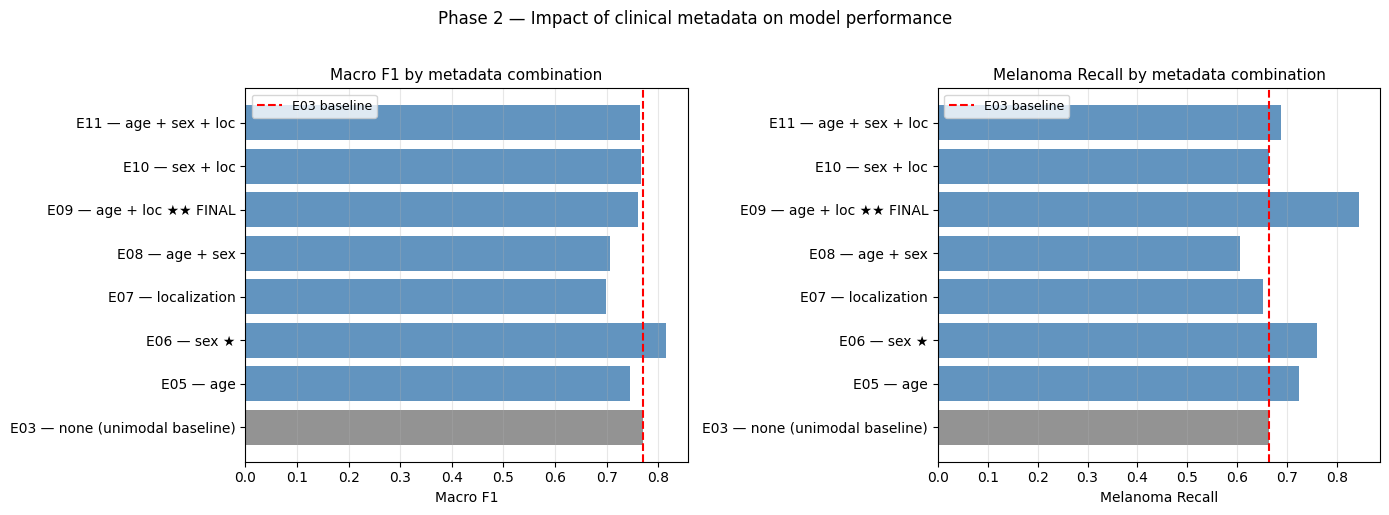

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Macro F1
colors_p2 = ['gray'] + ['steelblue'] * 7
axes[0].barh(df_p2.index, df_p2['Macro F1'], color=colors_p2, alpha=0.85)
axes[0].axvline(df_p2.loc['E03 — none (unimodal baseline)', 'Macro F1'],
                color='red', linestyle='--', linewidth=1.5, label='E03 baseline')
axes[0].set_title('Macro F1 by metadata combination', fontsize=11)
axes[0].set_xlabel('Macro F1')
axes[0].legend(fontsize=9)
axes[0].grid(axis='x', alpha=0.3)

# Melanoma Recall
axes[1].barh(df_p2.index, df_p2['Melanoma Recall ⚠'], color=colors_p2, alpha=0.85)
axes[1].axvline(df_p2.loc['E03 — none (unimodal baseline)', 'Melanoma Recall ⚠'],
                color='red', linestyle='--', linewidth=1.5, label='E03 baseline')
axes[1].set_title('Melanoma Recall by metadata combination', fontsize=11)
axes[1].set_xlabel('Melanoma Recall')
axes[1].legend(fontsize=9)
axes[1].grid(axis='x', alpha=0.3)

plt.suptitle('Phase 2 — Impact of clinical metadata on model performance',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

### Phase 2 Conclusion — Final Model Selection

**Selected model: E09 — Color Constancy + age + localization (seed=42)**

- E09 achieves the highest Melanoma Recall (0.844) across all Phase 2 
  experiments — a +0.180 improvement over the unimodal baseline E03 (0.665).
- E06 (sex) obtains a higher Macro F1 (0.816 vs 0.761), but multi-seed 
  analysis reveals high instability (std F1: 0.049 vs 0.013 for E09).
- E09 is four times more stable than E06 across seeds, with a nearly 
  constant ROC-AUC (0.971 ± 0.001).
- Age and localization are established clinical risk factors in oncological 
  dermatology, providing a strong clinical justification for their inclusion.

In a clinical decision support system, stability and Melanoma Recall take 
priority over absolute Macro F1 on a single favourable seed. E09 is selected 
as the final model for XAI analysis and Streamlit deployment.

| | E03 (baseline) | E06 (sex) | E09 (final) |
|---|---|---|---|
| Macro F1 | 0.770 | 0.816 | 0.761 |
| Melanoma Recall | 0.665 | 0.761 | 0.844 |
| ROC-AUC | 0.969 | 0.972 | 0.971 |
| Std F1 (multi-seed) | — | 0.049 | 0.013 |